# Wing MDO: Aerodynamics + Structures
### MECH 559 — Systems Optimization
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

This notebook treats the **airfoil cross-section as the beam cross-section** of a wing.  
Both disciplines are evaluated simultaneously in a **Multidisciplinary Design Optimization (MDO)** context.

**Contents:**
1. Problem formulation and MDO context
2. XDSM diagram
3. Discipline analysis models
4. Bidirectional coupling and MDF iteration
5. Design space exploration (coupled system)
6. Single-objective MDO: minimize drag
7. Pareto front: drag vs structural weight

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

plt.rcParams.update({'font.size': 12, 'figure.dpi': 110})

---
## 1. Problem Formulation

A rectangular wing is modeled as:
- An **aerodynamic surface** (generates lift, incurs drag)
- A **structural beam** (carries the bending load due to lift)

The **airfoil section** (chord $c$, thickness ratio $\tau=t/c$, max camber $m$) appears in **both
disciplines** in different ways: $\tau$ and $c$ enter both Aerodynamics and Structures, while
camber $m$ only enters Aerodynamics, where it sets the wing's *trim angle of attack*.

### Design variables
$$\mathbf{x} = [\tau,\; c,\; m]^\top, \qquad \tau \in [0.06,\, 0.20], \quad c \in [0.8,\, 2.0]\text{ m},
\quad m \in [0.00,\, 0.09]$$

$\tau$ and $c$ are unchanged from the earlier 2-variable version of this problem. $m$ is the
**maximum camber** (1st NACA four-digit parameter, same convention as the airfoil notebook), with
camber position $p=0.4$ held fixed as a model parameter.

### Coupling variables (state variables)
| Variable | Produced by | Consumed by | Physical meaning |
|---|---|---|---|
| $W_{struct}$ | Structures | Aerodynamics | Wing structural weight feeds total weight |
| $W_{total}$ | Aerodynamics | Structures | Total weight drives the bending load |

### $C_L$ is fixed by trim; the angle of attack is not

Level flight requires lift = weight, so $C_L = W_{total}/(qS)$ is **pinned by trim** — it is a
computed quantity here, exactly as in the airfoil notebook, just derived from a different physical
condition (force equilibrium, not a free operating choice). What camber controls is *not* $C_L$ but
the **angle of attack needed to realize that trim $C_L$**, via the same thin-airfoil-with-camber
relation used in the airfoil notebook:
$$\alpha_{trim}(\tau,c,m) = \alpha_{L0}(m,p) + \frac{C_L(\tau,c)}{2\pi}$$

$D$, $W_{struct}$, and the drag-minimizing optimum **do not depend on $m$** — camber's only role
here is to keep $\alpha_{trim}$ inside an operational envelope $[\alpha_{op,\min}, \alpha_{op,\max}]$,
a stand-in for the handling-quality / stall-margin requirements that real aircraft designers trade
against pure aerodynamic efficiency. This is a genuine MDO pattern: not every design variable moves
the objective — some exist only to keep an auxiliary output feasible.

### Objective and constraints
$$\min_{\tau,\, c,\, m} \; D(\tau, c) \quad \text{s.t.} \quad \sigma_{\max} \leq \sigma_{allow},\;
C_{L,\min} \leq C_L \leq C_{L,\max}, \; A(\tau,c) < 1, \;
\alpha_{op,\min} \leq \alpha_{trim}(\tau,c,m) \leq \alpha_{op,\max}$$

where $A = k_s b_s^2/(c^2\tau)$ is the structural weight fraction (must be $< 1$ for a physically realizable design).

In [3]:
# ── Shared parameters ─────────────────────────────────────────────────────────
b_s       = 12.0       # total wing span [m]
W_0       = 15000.0    # payload + fixed empty weight [N]
V         = 80.0       # cruise speed [m/s]
rho_a     = 1.225      # air density [kg/m³]
q         = 0.5 * rho_a * V**2   # dynamic pressure [Pa]

# Aerodynamics parameters (from airfoil notebook)
c_f       = 0.003      # turbulent skin-friction
e_oswald  = 0.85       # Oswald efficiency
CL_min_fl = 0.20       # minimum lift (trimmed flight)
CL_max_fl = 1.20       # stall limit

# Camber / trim-attitude parameters (NACA four-digit lift model, from airfoil notebook)
p_camber     = 0.40                 # camber position (2nd NACA digit), fixed
alpha_op_min = np.radians(-2.0)     # min sensible trim angle of attack
alpha_op_max = np.radians(10.0)     # max sensible trim angle of attack (stall-margin proxy)
m_min, m_max = 0.00, 0.09           # max camber bounds (1st NACA digit, 0-9%)

# Structural parameters (from beam notebook)
E_mod      = 70.0e9    # Young's modulus [Pa]
sigma_all  = 50.0e6    # allowable stress [Pa]
k_s        = 1.0e-4    # structural weight parameter (Greenwald-style)

# Bounds on design variables
tau_min, tau_max = 0.06, 0.20
c_min,   c_max   = 0.80, 2.00   # chord [m]

# ── NACA four-digit camber-lift model (same as the airfoil notebook) ──────────
def naca4_dyc_dx(x, m, p=p_camber):
    """Slope dyc/dx of the NACA four-digit mean camber line."""
    x = np.atleast_1d(np.asarray(x, dtype=float))
    dydx = np.zeros_like(x)
    if m > 0:
        front = x < p
        dydx[front] = (2*m/p**2) * (p - x[front])
        back = ~front
        dydx[back] = (2*m/(1-p)**2) * (p - x[back])
    return dydx

def alpha_L0(m, p=p_camber, n=2000):
    """Zero-lift angle of attack (rad) from thin-airfoil theory."""
    if m == 0:
        return 0.0
    theta = np.linspace(1e-6, np.pi - 1e-6, n)
    x = 0.5 * (1 - np.cos(theta))
    dydx = naca4_dyc_dx(x, m, p)
    if not hasattr(np, "trapz"):
      np.trapz = np.trapezoid
    return -(1/np.pi) * np.trapz(dydx * (np.cos(theta) - 1), theta)

print(f"Dynamic pressure q = {q:.1f} Pa")
print(f"Structural feasibility requires c²τ > {k_s*b_s**2:.4f} m²")
print(f"  → at c_min={c_min}: τ > {k_s*b_s**2/c_min**2:.4f}  (bound: {tau_min:.2f})")
print(f"Trim AoA envelope: [{np.degrees(alpha_op_min):.1f}°, {np.degrees(alpha_op_max):.1f}°]")

Dynamic pressure q = 3920.0 Pa
Structural feasibility requires c²τ > 0.0144 m²
  → at c_min=0.8: τ > 0.0225  (bound: 0.06)
Trim AoA envelope: [-2.0°, 10.0°]


---
## 2. XDSM Diagram (Generated with pyXDSM)

The **eXtended Design Structure Matrix (XDSM)** (Lambe & Martins, 2012) represents the MDO
problem architecture: disciplines on the diagonal, data flows off-diagonal.

In this notebook, the figure is generated using the `pyXDSM` package, which can produce:
- a `.tex` source file (for direct LaTeX workflows), and
- a rendered output (PDF/SVG depending on local LaTeX setup).

If `pyXDSM` is not installed in your kernel, install it with:

```python
%pip install pyXDSM
```

If LaTeX is unavailable locally, you can still use the generated `.tex` file in the course slide/report pipeline.

Generated TeX: generated_xdsm/wing_mdo_xdsm.tex
Running: latexmk -pdf -interaction=nonstopmode -halt-on-error -outdir=generated_xdsm generated_xdsm/wing_mdo_xdsm.tex
Compiled PDF: generated_xdsm/wing_mdo_xdsm.pdf


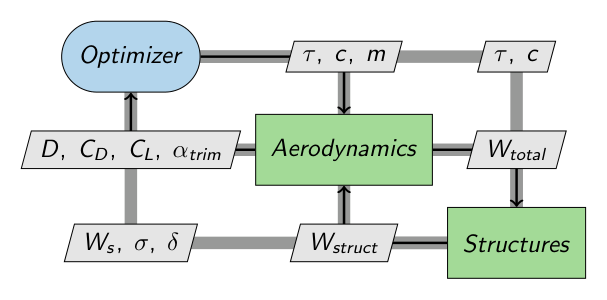

In [4]:
from pathlib import Path
import shutil
import subprocess
from IPython.display import IFrame, Image, Markdown, display

# Build path for generated XDSM assets
xdsm_dir = Path('generated_xdsm')
xdsm_dir.mkdir(exist_ok=True)
xdsm_base = xdsm_dir / 'wing_mdo_xdsm'
tex_path = xdsm_base.with_suffix('.tex')
pdf_target = xdsm_base.with_suffix('.pdf')
png_preview = xdsm_base.with_suffix('.png')

try:
    from pyxdsm.XDSM import XDSM, OPT, FUNC
except Exception as exc:
    raise ImportError(
        "pyXDSM is not available in this kernel. Run `%pip install pyXDSM` and re-run this cell."
    ) from exc

x = XDSM()

# Diagonal systems
x.add_system('opt', OPT, r'Optimizer')
x.add_system('aer', FUNC, r'Aerodynamics')
x.add_system('str', FUNC, r'Structures')

# Data flow connections
x.connect('opt', 'aer', r'\tau,\;c,\;m')
x.connect('opt', 'str', r'\tau,\;c')
x.connect('aer', 'str', r'W_{total}')
x.connect('str', 'aer', r'W_{struct}')
x.connect('aer', 'opt', r'D,\;C_D,\;C_L,\;\alpha_{trim}')
x.connect('str', 'opt', r'W_s,\;\sigma,\;\delta')

# MDF execution loop: OPT -> AER -> STR -> AER -> OPT
x.add_process(['opt', 'aer', 'str', 'aer', 'opt'])

# Always generate TeX source first (no build in this step).
# Use POSIX separators so TeX \input paths are portable on Windows too.
x.write(xdsm_base.as_posix(), build=False)
print(f'Generated TeX: {tex_path.as_posix()}')

# Compile TeX and force outputs into generated_xdsm/.
tex_arg = tex_path.as_posix()
commands = []
if shutil.which('latexmk'):
    commands.append([
        'latexmk', '-pdf', '-interaction=nonstopmode', '-halt-on-error',
        '-outdir=generated_xdsm', tex_arg
    ])
if shutil.which('pdflatex'):
    commands.append([
        'pdflatex', '-interaction=nonstopmode', '-halt-on-error',
        '-output-directory', 'generated_xdsm', tex_arg
    ])
    commands.append([
        'pdflatex', '-interaction=nonstopmode', '-halt-on-error',
        '-output-directory', 'generated_xdsm', tex_arg
    ])

pdf_candidates = [
    pdf_target,
    Path('wing_mdo_xdsm.pdf'),
]

compiled = False
for cmd in commands:
    print('Running:', ' '.join(cmd))
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print('Command failed; stderr tail:')
        print('\n'.join(result.stderr.splitlines()[-10:]))

    if any(p.exists() for p in pdf_candidates):
        compiled = True
        break

pdf_found = next((p for p in pdf_candidates if p.exists()), None)
if compiled and pdf_found is not None:
    # Normalize final location: keep the PDF under generated_xdsm/.
    if pdf_found != pdf_target:
        shutil.copy2(pdf_found, pdf_target)
        pdf_found = pdf_target

    print(f'Compiled PDF: {pdf_found.as_posix()}')
#     display(Markdown(f'**Compiled PDF:** `{pdf_found.as_posix()}`'))
#     display(IFrame(src=pdf_found.as_posix(), width=900, height=620))

    # Show first page as an image in cell output (if PyMuPDF is available).
    try:
        import pymupdf
        with pymupdf.open(pdf_found.as_posix()) as doc:
            pix = doc[0].get_pixmap(dpi=180)
            pix.save(png_preview.as_posix())
        # display(Markdown(f'**PDF Preview Image:** `{png_preview.as_posix()}`'))
        display(Image(filename=png_preview.as_posix(), width=900))
    except Exception as preview_err:
        print('Image preview was not generated.')
        print('Install PyMuPDF to enable image preview: %pip install pymupdf')
        print(f'Preview error: {type(preview_err).__name__}: {preview_err}')
else:
    print('PDF was not generated in this environment.')
    print('Install a TeX distribution with latexmk/pdflatex and rerun this cell.')
    print('TeX source is ready for external build:', tex_path.as_posix())

---
## 3. Discipline Analysis Models

### Aerodynamics (AER)
Given $W_{struct}$ from STR and design variables $(\tau, c, m)$:
$$S = b_s c, \quad AR = b_s/c, \quad W_{total} = W_0 + W_{struct}$$
$$C_L = \frac{W_{total}}{q\,S}, \quad
C_D = c_f(1+2\tau+60\tau^4) + \frac{C_L^2}{\pi\,AR\,e}, \quad
D = q\,S\,C_D$$

Camber $m$ does **not** enter $C_D$ or $D$ in this model — the empirical profile-drag correlation
is the same function of $\tau$ only used in the airfoil notebook. Instead, $m$ sets the **trim
angle of attack** needed to realize the (trim-determined) $C_L$, via thin-airfoil theory with
camber:
$$\alpha_{trim} = \alpha_{L0}(m, p) + \frac{C_L}{2\pi}$$

### Structures (STR)
Given $W_{total}$ from AER and design variables $(\tau, c)$ (camber has no structural role in
this model):

**Structural weight** (Greenwald-inspired: proportional to bending moment / section modulus):
$$W_{struct} = \frac{k_s\, b_s^2\, W_{total}}{c^2\, \tau}$$

**Max bending stress** (beam model, uniform distributed lift over semi-span $\ell = b_s/2$, rectangular section $c \times \tau c$):
$$M_{root} = \frac{W_{total}\,b_s}{8}, \qquad I = \frac{c\,(\tau c)^3}{12}, \qquad
\sigma_{\max} = \frac{M_{root}\,(\tau c/2)}{I} = \frac{3\,W_{total}\,b_s}{4\,c^3\,\tau^2}$$

**Tip deflection:**
$$\delta_{tip} = \frac{3\,W_{total}\,b_s^3}{32\,E\,c^4\,\tau^3}$$

### Coupling
Substituting $W_{struct}$ into $W_{total} = W_0 + W_{struct}$ gives an implicit equation. Let $A = k_s b_s^2/(c^2\tau)$:
$$W_{struct} = A\,W_{total}, \quad W_{total} = W_0 + A\,W_{total} \;\Longrightarrow\;
\boxed{W_{total}^* = \frac{W_0}{1 - A}, \quad W_{struct}^* = \frac{A\,W_0}{1-A}}$$
valid for $A < 1$, i.e., $c^2\tau > k_s b_s^2$. This coupling loop does not involve $m$ — camber
is evaluated *after* the coupling is resolved, purely as an AER post-processing output.

In [5]:
# ── Individual discipline functions ───────────────────────────────────────────
def aero(tau, c, W_struct, m):
    """Aerodynamics discipline."""
    S       = b_s * c
    AR      = b_s / c
    W_total = W_0 + W_struct
    CL      = W_total / (q * S)
    CD      = c_f * (1 + 2*tau + 60*tau**4) + CL**2 / (np.pi * AR * e_oswald)
    D       = q * S * CD
    alpha_trim = alpha_L0(m, p_camber) + CL / (2*np.pi)
    return dict(W_total=W_total, S=S, AR=AR, CL=CL, CD=CD, D=D, alpha_trim=alpha_trim)

def struct(tau, c, W_total):
    """Structures discipline (camber has no structural role in this model)."""
    A        = k_s * b_s**2 / (c**2 * tau)
    W_struct = A * W_total
    sigma    = 3 * W_total * b_s / (4 * c**3 * tau**2)
    delta    = 3 * W_total * b_s**3 / (32 * E_mod * c**4 * tau**3)
    return dict(W_struct=W_struct, A=A, sigma=sigma, delta=delta)

# ── Coupled analytical solution ────────────────────────────────────────────────
def coupled_solution(tau, c, m):
    """Closed-form MDF solution."""
    A = k_s * b_s**2 / (c**2 * tau)
    if np.any(A >= 1.0):
        return None   # infeasible
    W_total  = W_0 / (1.0 - A)
    W_struct = A * W_total
    aer = aero(tau, c, W_struct, m)
    str_ = struct(tau, c, W_total)
    return {**aer, **str_, 'W_total': W_total, 'W_struct': W_struct, 'A': A}

# ── Sanity check at nominal design ────────────────────────────────────────────
tau_nom, c_nom, m_nom = 0.12, 1.2, 0.02
sol = coupled_solution(tau_nom, c_nom, m_nom)
print(f"Nominal design: τ = {tau_nom:.2f}, c = {c_nom:.2f} m, m = {m_nom*100:.1f}%")
print(f"  Structural weight fraction A = {sol['A']:.3f}")
print(f"  W_struct  = {sol['W_struct']:.0f} N   ({sol['W_struct']/sol['W_total']*100:.1f}% of W_total)")
print(f"  W_total   = {sol['W_total']:.0f} N")
print(f"  C_L       = {sol['CL']:.4f}  (bounds: [{CL_min_fl}, {CL_max_fl}])")
print(f"  C_D       = {sol['CD']*1e4:.1f} drag counts")
print(f"  D         = {sol['D']:.1f} N   → L/D = {sol['W_total']/sol['D']:.1f}")
print(f"  σ_max     = {sol['sigma']/1e6:.2f} MPa  (allow: {sigma_all/1e6:.0f} MPa)")
print(f"  δ_tip     = {sol['delta']*1e3:.2f} mm")
print(f"  α_trim    = {np.degrees(sol['alpha_trim']):.2f}°  (envelope: [{np.degrees(alpha_op_min):.1f}°, {np.degrees(alpha_op_max):.1f}°])")

Nominal design: τ = 0.12, c = 1.20 m, m = 2.0%
  Structural weight fraction A = 0.083
  W_struct  = 1364 N   (8.3% of W_total)
  W_total   = 16364 N
  C_L       = 0.2899  (bounds: [0.2, 1.2])
  C_D       = 69.0 drag counts
  D         = 389.7 N   → L/D = 42.0
  σ_max     = 5.92 MPa  (allow: 50 MPa)
  δ_tip     = 10.57 mm
  α_trim    = 0.57°  (envelope: [-2.0°, 10.0°])


---
## 4. Bidirectional Coupling and MDF Iteration

In **Multidisciplinary Feasible (MDF)** architecture, the coupling is resolved
by iterating between disciplines (Gauss-Seidel fixed-point iteration) until
the coupling residual $|W_{total}^{(k+1)} - W_{total}^{(k)}|$ converges.

For this particular model the iteration is linear and converges in closed form,
but we demonstrate the iteration to illustrate the principle.

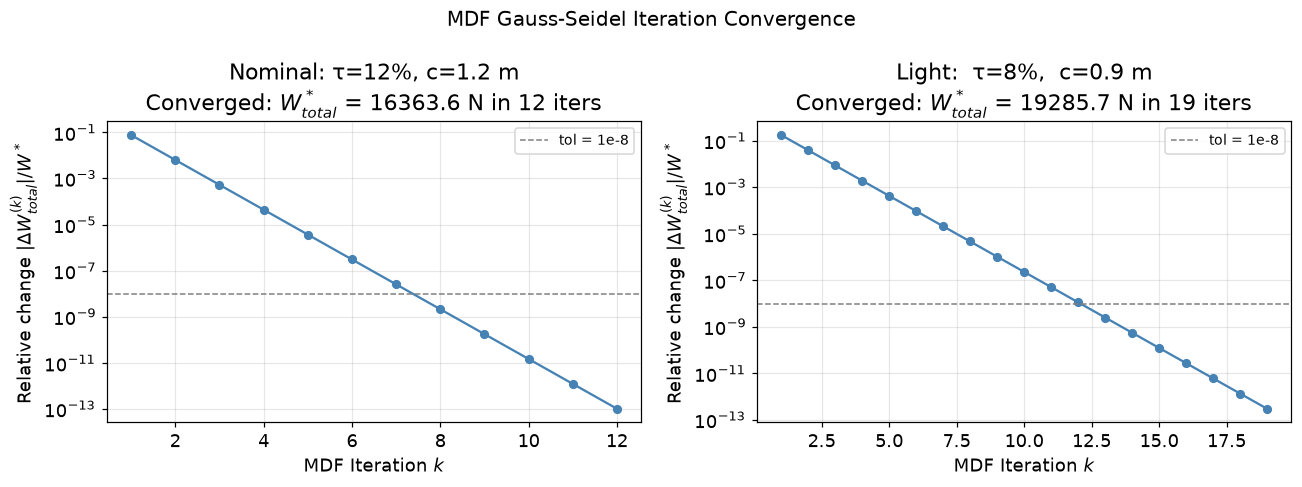

In [6]:
def mdf_iterate(tau, c, max_iter=50, tol=1e-8):
    """Gauss-Seidel MDF iteration (camber m plays no role in this coupling loop)."""
    W_total_hist = [W_0]       # start: assume no structural weight
    W_total = W_0
    for k in range(max_iter):
        str_out  = struct(tau, c, W_total)
        W_struct = str_out['W_struct']
        W_total_new = W_0 + W_struct
        W_total_hist.append(W_total_new)
        if abs(W_total_new - W_total) < tol:
            W_total = W_total_new
            break
        W_total = W_total_new
    return W_total, W_total_hist

# Demonstrate at two designs
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

test_designs = [(0.12, 1.2, 'Nominal: τ=12%, c=1.2 m'),
                (0.08, 0.9, 'Light:  τ=8%,  c=0.9 m')]

for ax, (tau_t, c_t, lbl) in zip(axes, test_designs):
    W_conv, hist = mdf_iterate(tau_t, c_t)
    W_analytic   = coupled_solution(tau_t, c_t, m_nom)['W_total']
    iters = np.arange(len(hist))
    ax.semilogy(iters[1:],
                np.abs(np.diff(hist)) / W_analytic,
                'o-', color='steelblue', ms=5)
    ax.axhline(1e-8, color='gray', ls='--', lw=1, label='tol = 1e-8')
    ax.set_xlabel('MDF Iteration $k$')
    ax.set_ylabel('Relative change $|\\Delta W_{total}^{(k)}|/W^*$')
    ax.set_title(f'{lbl}\nConverged: $W_{{total}}^*$ = {W_analytic:.1f} N in {len(hist)-1} iters')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('MDF Gauss-Seidel Iteration Convergence', fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Design Space Exploration (Coupled System)

We now evaluate the fully coupled MDO system over the design space $(\tau, c)$
and visualize objectives and constraints. $D$, $\sigma_{\max}$, and $W_{struct}$ do not depend on
camber, so these three panels are exactly as in the 2-variable version. A fourth panel shows the
**trim angle of attack at zero camber** ($m=0$, symmetric section) — where it falls outside the
operational envelope is precisely where camber becomes *necessary*, not optional.

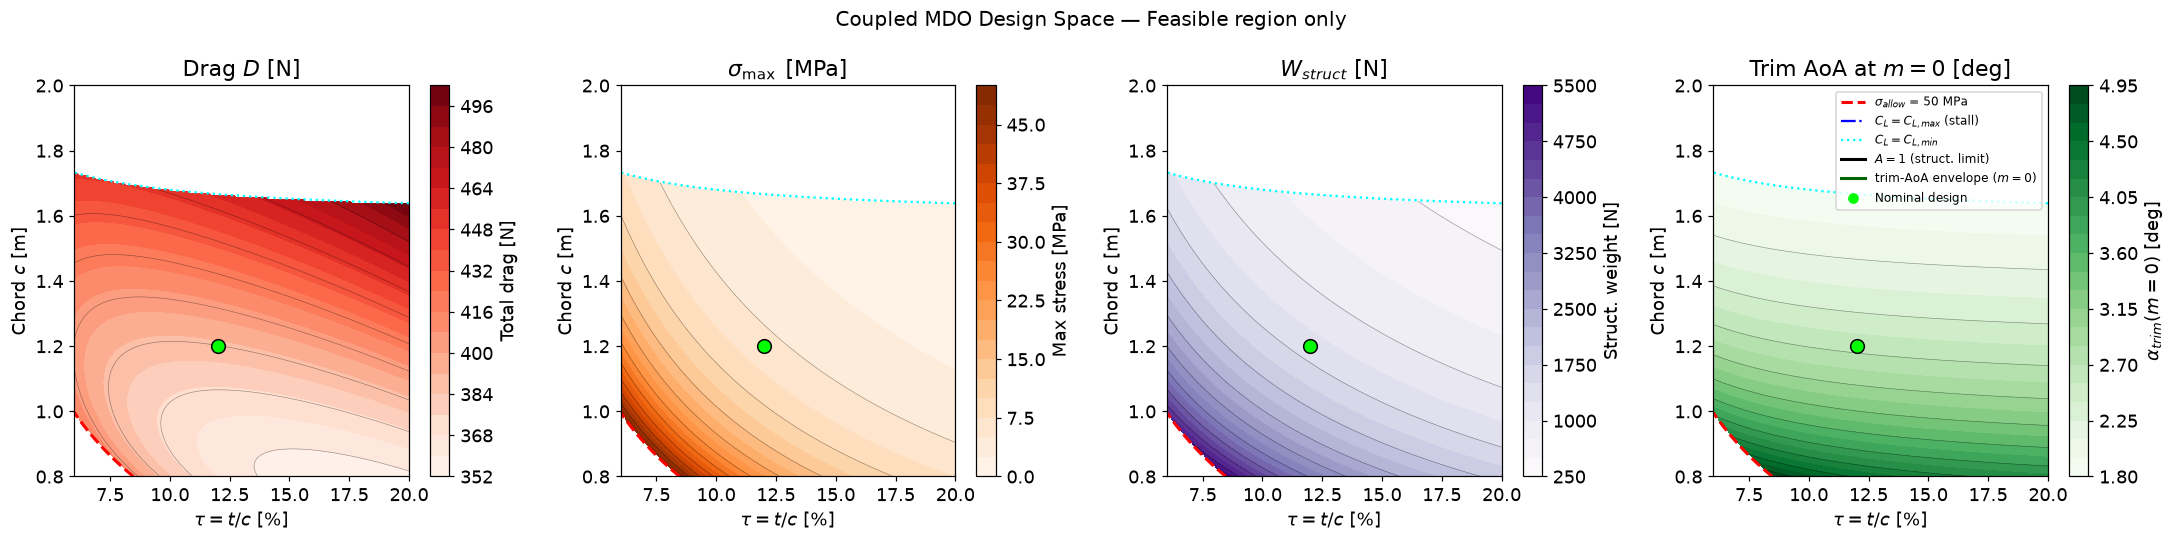

In [7]:
tau_grid_1d = np.linspace(tau_min, tau_max, 200)
c_grid_1d   = np.linspace(c_min,   c_max,   200)
TAU, C_G    = np.meshgrid(tau_grid_1d, c_grid_1d)

A_grid      = k_s * b_s**2 / (C_G**2 * TAU)
feasible_A  = A_grid < 1.0            # structural feasibility

# Compute coupled solutions on grid (vectorized using closed-form)
W_tot_grid  = np.where(feasible_A, W_0 / (1 - A_grid), np.nan)
W_str_grid  = np.where(feasible_A, A_grid * W_tot_grid, np.nan)
S_grid      = b_s * C_G
CL_grid     = W_tot_grid / (q * S_grid)
AR_grid     = b_s / C_G
CD_grid     = c_f*(1 + 2*TAU + 60*TAU**4) + CL_grid**2/(np.pi*AR_grid*e_oswald)
D_grid      = q * S_grid * CD_grid
sigma_grid  = 3 * W_tot_grid * b_s / (4 * C_G**3 * TAU**2)

# Trim angle of attack at zero camber (alpha_L0(0,.) = 0) -- none of D/sigma/W_struct/CL
# depend on camber m, only alpha_trim does, so this is the one grid that changes with m.
alpha_trim_m0_grid = np.degrees(CL_grid / (2*np.pi))

# Feasibility masks
feas_stress = sigma_grid <= sigma_all
feas_CL_max = CL_grid    <= CL_max_fl
feas_CL_min = CL_grid    >= CL_min_fl
feas_all    = feasible_A & feas_stress & feas_CL_max & feas_CL_min

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

quantities = [
    (D_grid,               'Drag $D$ [N]',              'Reds',    'Total drag [N]'),
    (sigma_grid/1e6,       '$\\sigma_{\\max}$ [MPa]',    'Oranges', 'Max stress [MPa]'),
    (W_str_grid,           '$W_{struct}$ [N]',           'Purples', 'Struct. weight [N]'),
    (alpha_trim_m0_grid,   r'Trim AoA at $m=0$ [deg]',   'Greens',  r'$\alpha_{trim}(m{=}0)$ [deg]'),
]

for ax, (G, lbl, cmap, clbl) in zip(axes, quantities):
    G_plot = np.where(feas_all, G, np.nan)  # only show feasible region
    cs = ax.contourf(tau_grid_1d*100, c_grid_1d, G_plot, levels=20, cmap=cmap)
    ax.contour(tau_grid_1d*100, c_grid_1d, G_plot, levels=10,
               colors='k', linewidths=0.4, alpha=0.4)
    plt.colorbar(cs, ax=ax, label=clbl)

    # Constraint boundaries
    ax.contour(tau_grid_1d*100, c_grid_1d, sigma_grid/1e6,
               levels=[sigma_all/1e6], colors='red', linewidths=2, linestyles='--')
    ax.contour(tau_grid_1d*100, c_grid_1d, CL_grid,
               levels=[CL_min_fl, CL_max_fl], colors=['cyan', 'blue'],
               linewidths=[1.5, 1.5], linestyles=[':', '-.'])
    ax.contour(tau_grid_1d*100, c_grid_1d, A_grid,
               levels=[1.0], colors='black', linewidths=2)

    ax.set_xlabel('$\\tau = t/c$ [%]')
    ax.set_ylabel('Chord $c$ [m]')
    ax.set_title(lbl)
    ax.scatter([tau_nom*100], [c_nom], color='lime', s=80, zorder=6,
               edgecolors='black', label='Nominal design')

# Trim-AoA envelope lines, only meaningful on the 4th panel
axes[3].contour(tau_grid_1d*100, c_grid_1d, alpha_trim_m0_grid,
                 levels=[np.degrees(alpha_op_min), np.degrees(alpha_op_max)],
                 colors='darkgreen', linewidths=2, linestyles='-')

# Legend for constraint lines
from matplotlib.lines import Line2D
legend_lines = [
    Line2D([0],[0], color='red',   lw=2, ls='--', label=f'$\\sigma_{{allow}}$ = {sigma_all/1e6:.0f} MPa'),
    Line2D([0],[0], color='blue',  lw=1.5, ls='-.', label='$C_L = C_{L,max}$ (stall)'),
    Line2D([0],[0], color='cyan',  lw=1.5, ls=':',  label='$C_L = C_{L,min}$'),
    Line2D([0],[0], color='black', lw=2,   ls='-',  label='$A=1$ (struct. limit)'),
    Line2D([0],[0], color='darkgreen', lw=2, ls='-', label='trim-AoA envelope ($m=0$)'),
    Line2D([0],[0], color='lime',  marker='o', ls='', label='Nominal design'),
]
axes[3].legend(handles=legend_lines, loc='upper right', fontsize=8)

plt.suptitle('Coupled MDO Design Space — Feasible region only', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6. Single-Objective MDO: Minimize Drag

We solve the MDO problem using the **closed-form MDF solution** (no iterative coupling needed)
and pass the result to `scipy.optimize.minimize` (SLSQP).

In [8]:
def mdo_objective(x):
    tau, c, m = x
    sol = coupled_solution(tau, c, m)
    if sol is None:
        return 1e10
    return sol['D']

constraints_mdo = [
    # stress constraint
    {'type': 'ineq', 'fun': lambda x: sigma_all - coupled_solution(x[0], x[1], x[2])['sigma']},
    # stall: CL ≤ CL_max
    {'type': 'ineq', 'fun': lambda x: CL_max_fl - coupled_solution(x[0], x[1], x[2])['CL']},
    # minimum lift: CL ≥ CL_min
    {'type': 'ineq', 'fun': lambda x: coupled_solution(x[0], x[1], x[2])['CL'] - CL_min_fl},
    # structural feasibility: A < 1
    {'type': 'ineq', 'fun': lambda x: 1.0 - k_s*b_s**2/(x[1]**2*x[0]) - 0.01},
    # trim angle-of-attack envelope (camber's only role in this problem)
    {'type': 'ineq', 'fun': lambda x: alpha_op_max - coupled_solution(x[0], x[1], x[2])['alpha_trim']},
    {'type': 'ineq', 'fun': lambda x: coupled_solution(x[0], x[1], x[2])['alpha_trim'] - alpha_op_min},
]
bounds_mdo = [(tau_min, tau_max), (c_min, c_max), (m_min, m_max)]

# Multiple starting points for robustness
best_res = None
for x0 in [[0.12, 1.2, 0.02], [0.10, 1.5, 0.00], [0.15, 1.0, 0.05], [0.12, 1.8, 0.03]]:
    res = minimize(mdo_objective, x0, method='SLSQP',
                   bounds=bounds_mdo, constraints=constraints_mdo,
                   options={'ftol': 1e-10, 'maxiter': 500})
    if res.success and (best_res is None or res.fun < best_res.fun):
        best_res = res

tau_opt, c_opt, m_opt = best_res.x
sol_opt = coupled_solution(tau_opt, c_opt, m_opt)

print("MDO Optimum (minimize drag):")
print(f"  τ*        = {tau_opt*100:.2f}%")
print(f"  c*        = {c_opt:.4f} m  →  S* = {b_s*c_opt:.2f} m²,  AR* = {b_s/c_opt:.2f}")
print(f"  m*        = {m_opt*100:.2f}%  (D and W_struct don't depend on m -- any feasible camber")
print(f"              works; SLSQP simply leaves it wherever the trim-AoA constraint is satisfied)")
print(f"  W_struct* = {sol_opt['W_struct']:.1f} N  ({sol_opt['W_struct']/sol_opt['W_total']*100:.1f}% of W_total)")
print(f"  W_total*  = {sol_opt['W_total']:.1f} N")
print(f"  C_L*      = {sol_opt['CL']:.4f}")
print(f"  C_D*      = {sol_opt['CD']*1e4:.1f} drag counts")
print(f"  D*        = {sol_opt['D']:.2f} N  →  L/D* = {sol_opt['W_total']/sol_opt['D']:.1f}")
print(f"  σ_max*    = {sol_opt['sigma']/1e6:.2f} MPa  (allow: {sigma_all/1e6:.0f} MPa)")
print(f"  δ_tip*    = {sol_opt['delta']*1e3:.2f} mm")
print(f"  α_trim*   = {np.degrees(sol_opt['alpha_trim']):.2f}°  (envelope: [{np.degrees(alpha_op_min):.1f}°, {np.degrees(alpha_op_max):.1f}°])")
print(f"  Optimizer: {best_res.message}")

MDO Optimum (minimize drag):
  τ*        = 16.96%
  c*        = 0.8000 m  →  S* = 9.60 m²,  AR* = 15.00
  m*        = 2.00%  (D and W_struct don't depend on m -- any feasible camber
              works; SLSQP simply leaves it wherever the trim-AoA constraint is satisfied)
  W_struct* = 2294.5 N  (13.3% of W_total)
  W_total*  = 17294.5 N
  C_L*      = 0.4596
  C_D*      = 94.4 drag counts
  D*        = 355.22 N  →  L/D* = 48.7
  σ_max*    = 10.57 MPa  (allow: 50 MPa)
  δ_tip*    = 20.03 mm
  α_trim*   = 2.11°  (envelope: [-2.0°, 10.0°])
  Optimizer: Optimization terminated successfully


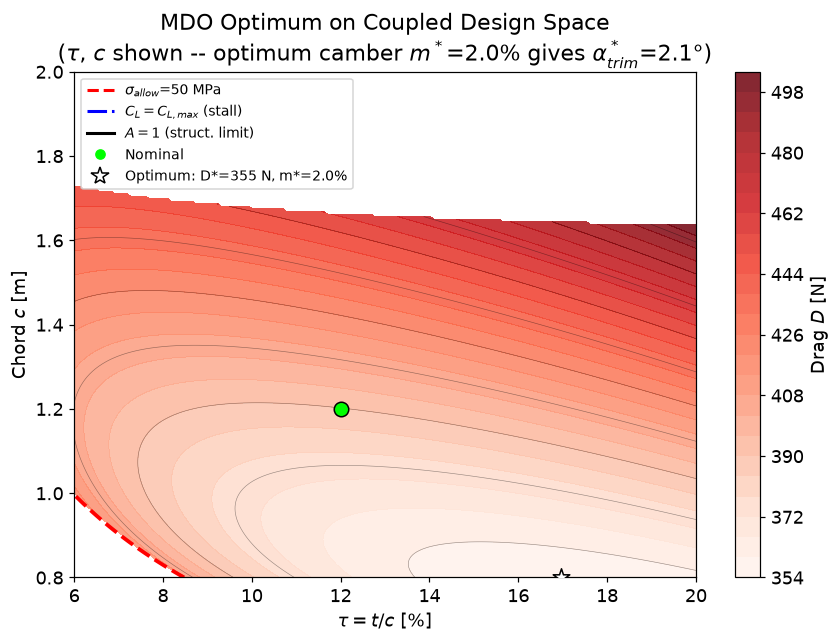

In [9]:
# ── Plot optimum on design space ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

D_feas = np.where(feas_all, D_grid, np.nan)
cs = ax.contourf(tau_grid_1d*100, c_grid_1d, D_feas, levels=25, cmap='Reds', alpha=0.85)
ax.contour(tau_grid_1d*100, c_grid_1d, D_feas, levels=12,
           colors='k', linewidths=0.4, alpha=0.4)
plt.colorbar(cs, ax=ax, label='Drag $D$ [N]')

ax.contour(tau_grid_1d*100, c_grid_1d, sigma_grid/1e6,
           levels=[sigma_all/1e6], colors='red', linewidths=2.5, linestyles='--')
ax.contour(tau_grid_1d*100, c_grid_1d, CL_grid,
           levels=[CL_max_fl], colors='blue', linewidths=2, linestyles='-.')
ax.contour(tau_grid_1d*100, c_grid_1d, A_grid,
           levels=[1.0], colors='black', linewidths=2)

ax.scatter([tau_nom*100], [c_nom], color='lime',  s=90, zorder=6, edgecolors='k', label='Nominal')
ax.scatter([tau_opt*100], [c_opt], color='white', s=130, zorder=7, edgecolors='k', marker='*',
           label=f'Optimum: D*={sol_opt["D"]:.0f} N, m*={m_opt*100:.1f}%')

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0],[0], color='red',   lw=2, ls='--', label=f'$\\sigma_{{allow}}$={sigma_all/1e6:.0f} MPa'),
    Line2D([0],[0], color='blue',  lw=2, ls='-.', label='$C_L=C_{L,max}$ (stall)'),
    Line2D([0],[0], color='black', lw=2, ls='-',  label='$A=1$ (struct. limit)'),
    Line2D([0],[0], color='lime',  marker='o', ls='', label='Nominal'),
    Line2D([0],[0], color='white', marker='*', ls='', markeredgecolor='k',
           markersize=12, label=f'Optimum: D*={sol_opt["D"]:.0f} N, m*={m_opt*100:.1f}%'),
], fontsize=9, loc='upper left')

ax.set_xlabel('$\\tau = t/c$ [%]')
ax.set_ylabel('Chord $c$ [m]')
ax.set_title('MDO Optimum on Coupled Design Space\n'
              f'($\\tau$, $c$ shown -- optimum camber $m^*$={m_opt*100:.1f}% gives '
              f'$\\alpha_{{trim}}^*$={np.degrees(sol_opt["alpha_trim"]):.1f}$\\degree$)')
ax.grid(False)
plt.tight_layout()
plt.show()

---
## 7. Pareto Front: Drag vs Structural Weight

Both $D$ (drag) and $W_{struct}$ (structural weight) are functions of the design.  
They **compete** through $\tau$: thin airfoil → less drag but heavier structure.

We apply the **$\varepsilon$-constraint method**:
$$\min_{\tau,c} D \quad \text{s.t.} \quad W_{struct} \leq \varepsilon_k, \; \sigma \leq \sigma_{allow}, \; C_L \in [C_{L,min}, C_{L,max}]$$

In [10]:
# Determine valid ε range from feasible design space
Ws_feas = W_str_grid[feas_all]
eps_lo_p = float(np.nanmin(Ws_feas)) * 1.05
eps_hi_p = float(np.nanmax(Ws_feas)) * 0.98
print(f"W_struct range in feasible space: [{eps_lo_p:.1f}, {eps_hi_p:.1f}] N")

n_pareto = 50
eps_vals = np.linspace(eps_lo_p, eps_hi_p, n_pareto)

D_par, Ws_par, tau_par, c_par, m_par, CL_par, sigma_par, alpha_par = [], [], [], [], [], [], [], []

for eps_k in eps_vals:
    cons_p = [
        {'type': 'ineq', 'fun': lambda x, e=eps_k: e - coupled_solution(x[0],x[1],x[2])['W_struct']},
        {'type': 'ineq', 'fun': lambda x: sigma_all - coupled_solution(x[0],x[1],x[2])['sigma']},
        {'type': 'ineq', 'fun': lambda x: CL_max_fl - coupled_solution(x[0],x[1],x[2])['CL']},
        {'type': 'ineq', 'fun': lambda x: coupled_solution(x[0],x[1],x[2])['CL'] - CL_min_fl},
        {'type': 'ineq', 'fun': lambda x: 1.0 - k_s*b_s**2/(x[1]**2*x[0]) - 0.01},
        {'type': 'ineq', 'fun': lambda x: alpha_op_max - coupled_solution(x[0],x[1],x[2])['alpha_trim']},
        {'type': 'ineq', 'fun': lambda x: coupled_solution(x[0],x[1],x[2])['alpha_trim'] - alpha_op_min},
    ]
    best_p = None
    for x0 in [[tau_opt, c_opt, m_opt], [0.10, 1.5, 0.02], [0.15, 1.2, 0.04]]:
        res = minimize(mdo_objective, x0, method='SLSQP',
                       bounds=bounds_mdo, constraints=cons_p,
                       options={'ftol': 1e-11, 'maxiter': 500})
        if res.success and (best_p is None or res.fun < best_p.fun):
            best_p = res
    if best_p is not None:
        s = coupled_solution(best_p.x[0], best_p.x[1], best_p.x[2])
        D_par.append(s['D']); Ws_par.append(s['W_struct'])
        tau_par.append(best_p.x[0]); c_par.append(best_p.x[1]); m_par.append(best_p.x[2])
        CL_par.append(s['CL']); sigma_par.append(s['sigma']); alpha_par.append(s['alpha_trim'])

D_par    = np.array(D_par);   Ws_par   = np.array(Ws_par)
tau_par  = np.array(tau_par); c_par    = np.array(c_par); m_par = np.array(m_par)
CL_par   = np.array(CL_par);  sigma_par= np.array(sigma_par); alpha_par = np.array(alpha_par)
print(f"Computed {len(D_par)}/{n_pareto} Pareto-optimal solutions.")

W_struct range in feasible space: [434.2, 5276.0] N
Computed 49/50 Pareto-optimal solutions.


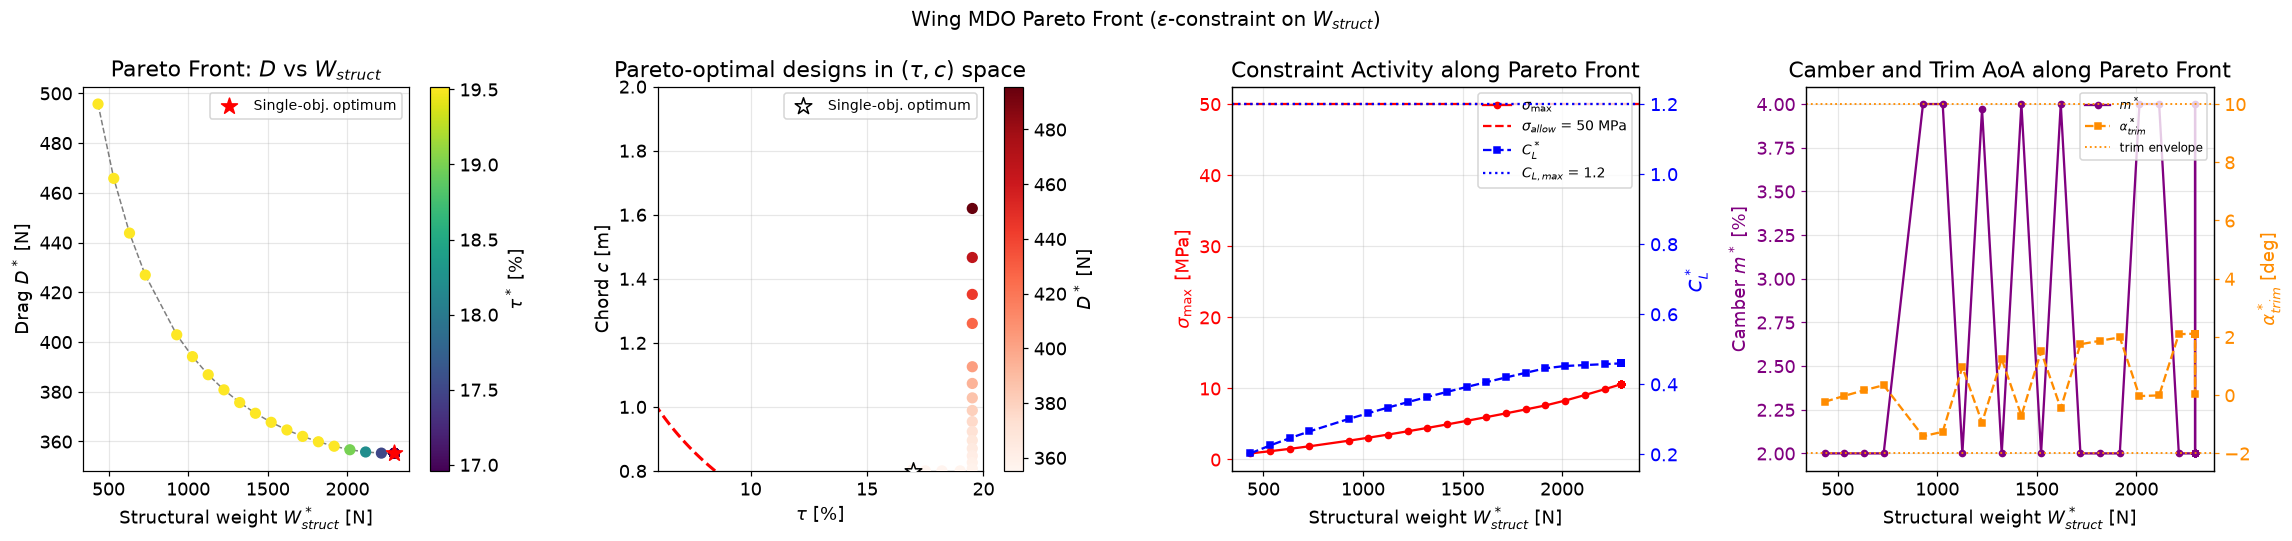

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(21, 5))

# Left: Pareto front — D vs W_struct
ax = axes[0]
sc = ax.scatter(Ws_par, D_par, c=tau_par*100, cmap='viridis', s=40, zorder=5)
ax.plot(Ws_par, D_par, 'k--', lw=1, alpha=0.5)
plt.colorbar(sc, ax=ax, label='$\\tau^*$ [%]')
ax.scatter([sol_opt['W_struct']], [sol_opt['D']], color='red', s=120, zorder=6,
           marker='*', label='Single-obj. optimum')
ax.set_xlabel('Structural weight $W_{struct}^*$ [N]')
ax.set_ylabel('Drag $D^*$ [N]')
ax.set_title('Pareto Front: $D$ vs $W_{struct}$')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 2nd: Pareto path in design space
ax = axes[1]
sc2 = ax.scatter(tau_par*100, c_par, c=D_par, cmap='Reds', s=40, zorder=5)
plt.colorbar(sc2, ax=ax, label='$D^*$ [N]')
ax.contour(tau_grid_1d*100, c_grid_1d, sigma_grid/1e6,
           levels=[sigma_all/1e6], colors='red', linewidths=2, linestyles='--')
ax.contour(tau_grid_1d*100, c_grid_1d, CL_grid,
           levels=[CL_max_fl], colors='blue', linewidths=1.5, linestyles='-.')
ax.scatter([tau_opt*100], [c_opt], color='white', s=130, zorder=7,
           edgecolors='k', marker='*', label='Single-obj. optimum')
ax.set_xlabel('$\\tau$ [%]')
ax.set_ylabel('Chord $c$ [m]')
ax.set_title('Pareto-optimal designs in $(\\tau, c)$ space')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# 3rd: constraint status along Pareto front
ax = axes[2]
ax.plot(Ws_par, sigma_par/1e6, 'o-', color='red', ms=4, label='$\\sigma_{\\max}$')
ax.axhline(sigma_all/1e6, color='red', ls='--', lw=1.5,
           label=f'$\\sigma_{{allow}}$ = {sigma_all/1e6:.0f} MPa')
ax2 = ax.twinx()
ax2.plot(Ws_par, CL_par, 's--', color='blue', ms=4, label='$C_L^*$')
ax2.axhline(CL_max_fl, color='blue', ls=':', lw=1.5,
            label=f'$C_{{L,max}}$ = {CL_max_fl}')
ax2.set_ylabel('$C_L^*$', color='blue')
ax2.tick_params(axis='y', colors='blue')
ax.set_xlabel('Structural weight $W_{struct}^*$ [N]')
ax.set_ylabel('$\\sigma_{\\max}$ [MPa]', color='red')
ax.tick_params(axis='y', colors='red')
ax.set_title('Constraint Activity along Pareto Front')
lines1, lbl1 = ax.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax.legend(lines1+lines2, lbl1+lbl2, fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

# 4th: camber and trim AoA along Pareto front -- shows m has no systematic trend
# with W_struct (it's decoupled from the objective), while alpha_trim tracks CL*
ax = axes[3]
ax.plot(Ws_par, m_par*100, 'o-', color='purple', ms=4, label='$m^*$')
ax.set_xlabel('Structural weight $W_{struct}^*$ [N]')
ax.set_ylabel('Camber $m^*$ [%]', color='purple')
ax.tick_params(axis='y', colors='purple')
ax3b = ax.twinx()
ax3b.plot(Ws_par, np.degrees(alpha_par), 's--', color='darkorange', ms=4, label='$\\alpha_{trim}^*$')
ax3b.axhline(np.degrees(alpha_op_min), color='darkorange', ls=':', lw=1.2)
ax3b.axhline(np.degrees(alpha_op_max), color='darkorange', ls=':', lw=1.2, label='trim envelope')
ax3b.set_ylabel('$\\alpha_{trim}^*$ [deg]', color='darkorange')
ax3b.tick_params(axis='y', colors='darkorange')
ax.set_title('Camber and Trim AoA along Pareto Front')
lines3, lbl3 = ax.get_legend_handles_labels()
lines4, lbl4 = ax3b.get_legend_handles_labels()
ax.legend(lines3+lines4, lbl3+lbl4, fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)

plt.suptitle('Wing MDO Pareto Front ($\\varepsilon$-constraint on $W_{struct}$)', fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

### MDO problem architecture

| | Aerodynamics (AER) | Structures (STR) |
|---|---|---|
| **Inputs (DV)** | $\tau$, $c$, $m$ | $\tau$, $c$ |
| **Coupling input** | $W_{struct}$ ← STR | $W_{total}$ ← AER |
| **Coupling output** | $W_{total}$ → STR | $W_{struct}$ → AER |
| **Outputs to OPT** | $D$, $C_D$, $C_L$, $\alpha_{trim}$ | $W_s$, $\sigma_{\max}$, $\delta_{tip}$ |

### Key MDO takeaways
- The **same design variables** $(\tau, c)$ appear in both disciplines — this is the essence of MDO.
- The **two-way coupling** ($W_{struct} \leftrightarrow W_{total}$) requires iterative or direct solution (MDF).
- The **XDSM** makes the data flow and execution order explicit at a glance.
- The **Pareto front** reveals that the drag-vs-weight tradeoff is driven primarily by $\tau$:
  thinner airfoil → less drag but more structural weight (direct conflict in $\tau$).
- The **single-objective optimum** ($\min D$) lies on the Pareto front where no weight constraint is active;
  imposing a structural weight budget ($W_s \leq \varepsilon_k$) selects a different Pareto point.
- Compared to the **uncoupled** notebooks, the coupled design has higher drag and structural weight
  than either sub-problem alone, illustrating the cost of multidisciplinary coupling.
- **Camber $m$ is a design variable that never moves the objective.** $C_L$ is pinned by trim
  (lift = weight), not chosen — computed exactly like in the airfoil notebook, just from a
  different physical condition. $D$ and $W_{struct}$ are functions of $C_L$, not of $m$, so $m$
  has zero gradient in this optimization. Its only job is keeping the **trim angle of attack**
  $\alpha_{trim}=\alpha_{L0}(m,p)+C_L/2\pi$ inside an operational envelope — a realistic example of
  an MDO design variable that exists purely to satisfy a secondary/handling-quality constraint,
  not to improve the primary objective.